[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/N_Label.ipynb)

# Librerie

In [ ]:
!pip install -q obspy
!git clone https://github.com/Mpinaz/Thesis.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 71.9 MB/s eta 0:00:00
Cloning into 'Thesis'...
remote: Enumerating objects: 656, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 656 (delta 99), reused 37 (delta 37), pack-reused 501 (from 1)
Receiving objects: 100% (656/656), 30.86 MiB | 22.38 MiB/s, done.
Resolving deltas: 100% (328/328), done.


In [ ]:
from obspy import read, Stream, UTCDateTime
from scipy.signal import stft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, f1_score

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px

import numpy as np
import pickle as pk
import copy
from collections import Counter, defaultdict
import pandas as pd

rng = np.random.default_rng(42)
rng_torch = torch.Generator().manual_seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparing Dataset

In [ ]:
catalog = pd.read_csv('/content/Thesis/Catalog.csv')

catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")
catalog["time"] = pd.to_datetime(catalog["time"], format="ISO8601", utc=True)

print(f"Loaded {len(catalog)} events")
catalog.head()

Loaded 11207 events


,time,lat,lon,depth_km,mag,FI_S,label
index,,,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42,-100.000,1
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01,-100.000,2
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97,-0.481,1
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96,-0.559,1
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86,-0.666,1


In [ ]:
with open("/content/drive/MyDrive/Datasets/Dataset_Tesi.pkl", "rb") as f:
    Data = pk.load(f)
print(f"{len(Data)} Samples")

118996 Samples


# 5 Label

In [ ]:
t = pd.to_datetime(catalog["time"], utc = "true")
N_Label = 5

First_Peiod = ((t > pd.Timestamp("2015-08-01", tz = "UTC")) & (t <=  pd.Timestamp("2015-09-15", tz = "UTC")))
FiP_set = set((catalog.index[First_Peiod].tolist()))

Second_Peiod = ((t > pd.Timestamp("2015-09-15", tz = "UTC")) & (t <=  pd.Timestamp("2015-11-01", tz = "UTC")))
SP_set = set((catalog.index[Second_Peiod].tolist()))

Third_Peiod = ((t > pd.Timestamp("2015-11-01", tz = "UTC")) & (t <=  pd.Timestamp("2015-12-4", tz = "UTC")))
TP_set = set((catalog.index[Third_Peiod].tolist()))

Fourth_Peiod = ((((t > pd.Timestamp("2016-02-15", tz = "UTC")) & (t <=  pd.Timestamp("2016-02-25", tz = "UTC")))))
FoP_set = set((catalog.index[Fourth_Peiod].tolist()))

Eruption = ((t >=  pd.Timestamp("2016-04-03", tz = "UTC")))
POST_set   = set((catalog.index[Eruption].tolist()))

In [ ]:
FP_list, SP_list, Erup_list = [], [], []
per_evento = defaultdict(list)

for (St, E, D) in Data:
    if E in FiP_set:
        FP_list.append((St, E, D))
    elif E in SP_set:
        SP_list.append((St, E, D))
    elif E in TP_set:
        TP_list.append((St, E, D))
    elif E in FoP_set:
        FourthP_list.append((St, E, D))
    elif E in POST_set:
        Erup_list.append((St, E, D))
    per_evento[E].append((St, E, D))

print(f"{len(FP_list)} Eventi First Period")
print(f"{len(SP_list)} Eventi Second Period")
print(f"{len(TP_list)} Eventi Third Period")
print(f"{len(FourthP_list)} Eventi Fourth Period")
print(f"{len(Erup_list)} Eventi Eruption")


period_lists = {
    0: FP_list,       # First Period
    1: SP_list,       # Second Period
    2: TP_list,       # Third Period
    3: FourthP_list,  # Fourth Period
    4: Erup_list,     # Eruption
}

17567 Eventi First Period
21251 Eventi Second Period
30867 Eventi Third Period
7645 Eventi Fourth Period
6447 Eventi Eruption


# 3 Label

In [ ]:
t = pd.to_datetime(catalog["time"], utc = "true")
N_Label = 3


First_Peiod = ((t > pd.Timestamp("2015-08-01", tz = "UTC")) & (t <=  pd.Timestamp("2015-12-04", tz = "UTC")))
FiP_set = set((catalog.index[First_Peiod].tolist()))

Second_Peiod = ((t > pd.Timestamp("2016-02-15", tz = "UTC")) & (t <=  pd.Timestamp("2016-02-25", tz = "UTC")))
SP_set = set((catalog.index[Second_Peiod].tolist()))

Eruption = ((t >=  pd.Timestamp("2016-04-03", tz = "UTC")))
POST_set   = set((catalog.index[Eruption].tolist()))

In [ ]:
FP_list, SP_list, TP_list, FourthP_list, Erup_list = [], [], [], [], []
per_evento = defaultdict(list)

for (St, E, D) in Data:
    if E in FiP_set:
        FP_list.append((St, E, D))
    elif E in SP_set:
        SP_list.append((St, E, D))
    elif E in POST_set:
        Erup_list.append((St, E, D))
    per_evento[E].append((St, E, D))

print(f"{len(FP_list)} Eventi First Period")
print(f"{len(SP_list)} Eventi Second Period")
print(f"{len(TP_list)} Eventi Third Period")
print(f"{len(FourthP_list)} Eventi Fourth Period")
print(f"{len(Erup_list)} Eventi Eruption")

# le liste con la rispettiva label
period_lists = {
    0: FP_list,       # First Period
    1: SP_list,       # Second Period
    2: Erup_list,     # Eruption
}

69685 Eventi First Period
7645 Eventi Second Period
0 Eventi Third Period
0 Eventi Fourth Period
6447 Eventi Eruption


# Split Dataset

In [ ]:
import random
from collections import defaultdict

random.seed(42)

# target = lunghezza della lista più corta
target = min(len(l) for l in period_lists.values())
print(f"Target samples per classe: {target}\n")

X, y = [], []
per_evento_finale = defaultdict(list)

for label, lst in period_lists.items():
    # raggruppo i sample per evento
    eventi = defaultdict(list)
    for (St, E, D) in lst:
        eventi[E].append((St, E, D))

    # ordino gli eventi in modo casuale
    chiavi = list(eventi.keys())
    random.shuffle(chiavi)

    count = 0
    for E in chiavi:
        if count >= target:
            break
        samples = eventi[E]
        # aggiungo TUTTI i sample dell'evento (non li spezzo)
        for s in samples:
            X.append(s)
            y.append(label)
            per_evento_finale[E].append(s)
        count += len(samples)   # può sforare leggermente

    print(f"Classe {label}: {count} samples da ~{len(chiavi)} eventi disponibili")

print(f"\nTotale dataset: {len(X)} samples, {len(set(y))} classi")

Target samples per classe: 6447

Classe 0: 6447 samples da ~6383 eventi disponibili
Classe 1: 6454 samples da ~718 eventi disponibili
Classe 2: 6447 samples da ~650 eventi disponibili

Totale dataset: 19348 samples, 3 classi


In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

X = np.array(X, dtype=object)
y = np.array(y)
groups = np.array([E for (St, E, D) in X])   # l'evento di ogni sample
groups = groups[(groups != 'Event 11208') & (groups != 'Event 11209')]

# --- Split 1: train (80%) vs temp (20%) ---
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups))

X_train, y_train = X[train_idx], y[train_idx]
X_temp,  y_temp  = X[temp_idx],  y[temp_idx]
groups_temp = groups[temp_idx]

# --- Split 2: val (50% del temp = 10%) vs test (50% del temp = 10%) ---
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val,  y_val  = X_temp[val_idx],  y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print(f"Train: {len(X_train)} samples")
print(f"Val:   {len(X_val)} samples")
print(f"Test:  {len(X_test)} samples")

# --- Verifica: nessun evento condiviso tra gli split ---
val_idx_abs  = temp_idx[val_idx]
test_idx_abs = temp_idx[test_idx]

assert set(groups[train_idx]).isdisjoint(groups[val_idx_abs])
assert set(groups[train_idx]).isdisjoint(groups[test_idx_abs])
assert set(groups[val_idx_abs]).isdisjoint(groups[test_idx_abs])

Train: 15554 samples
Val:   1965 samples
Test:  1829 samples


In [ ]:
def Train_Loop(model, history, Epochs, TrainLoader, ValLoader):
  device = "cuda" if torch.cuda.is_available() else "cpu"

  best_val_bacc = 0.0
  best_state = None

  pbar = tqdm(range(Epochs), desc="Training")
  for epoch in pbar:
      model.train()
      tot_loss, correct, total = 0.0, 0, 0
      for x, y in TrainLoader:
          x, y = x.to(device), y.to(device)

          opt.zero_grad()
          out = model(x)
          loss = crit(out, y)
          loss.backward()
          opt.step()

          tot_loss += loss.item() * x.size(0)
          correct  += (out.argmax(1) == y).sum().item()
          total    += x.size(0)

      train_loss = tot_loss / total
      train_acc  = correct / total

      # Validation

      model.eval()
      tot_loss, total = 0.0, 0
      val_true, val_pred = [], []
      with torch.no_grad():
          for x, y in ValLoader:
              x, y = x.to(device), y.to(device)
              out = model(x)
              loss = crit(out, y)

              tot_loss += loss.item() * x.size(0)
              total    += x.size(0)
              val_true.append(y.cpu())
              val_pred.append(out.argmax(1).cpu())

      val_loss = tot_loss / total
      val_true = torch.cat(val_true).numpy()
      val_pred = torch.cat(val_pred).numpy()
      val_acc  = (val_true == val_pred).mean()
      val_bacc = balanced_accuracy_score(val_true, val_pred)
      val_f1p  = f1_score(val_true, val_pred, average="macro")

      scheduler.step(val_loss)   # da attivare con lo scheduler

      history["train_loss"].append(train_loss)
      history["val_loss"].append(val_loss)
      history["train_acc"].append(train_acc)
      history["val_acc"].append(val_acc)
      history["val_bacc"].append(val_bacc)
      history["val_f1p"].append(val_f1p)

      if not (epoch + 1) % (Epochs // 4):
            tqdm.write(f"\nEpoch {epoch+1}\ntrain_acc={train_acc:.4f} | val_acc={val_acc:.3f} | val_bacc={val_bacc:.3f} | val_f1p={val_f1p:.3f}")

      if val_bacc > best_val_bacc:
          best_val_bacc = val_bacc
          best_state = copy.deepcopy(model.state_dict())

  model.load_state_dict(best_state)
  print(f"Best val balanced accuracy: {best_val_bacc:.4f}")

  return model, history

# CNN1D

In [ ]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [ ]:
# rimappa val/test dagli indici ORIGINALI di X/y (val_idx e test_idx indicizzano X_temp)
val_idx_abs  = temp_idx[val_idx]
test_idx_abs = temp_idx[test_idx]

train_ds_W = WaveDataset([X[i] for i in train_idx],     y[train_idx])
val_ds_W   = WaveDataset([X[i] for i in val_idx_abs],   y[val_idx_abs])
test_ds_W  = WaveDataset([X[i] for i in test_idx_abs],  y[test_idx_abs])

train_loader_Wave = DataLoader(train_ds_W, batch_size=32, shuffle=True, generator=rng_torch) # Togliere Generator per randomness
val_loader_Wave   = DataLoader(val_ds_W,   batch_size=32)
test_loader_Wave  = DataLoader(test_ds_W,  batch_size=32)

# verifica: nessun evento condiviso tra gli split
g = np.array([E for (St, E, D) in X])
print("Overlap train/val: ", len(set(g[train_idx]) & set(g[val_idx_abs])))
print("Overlap train/test:", len(set(g[train_idx]) & set(g[test_idx_abs])))
print("Overlap val/test:  ", len(set(g[val_idx_abs]) & set(g[test_idx_abs])))

Overlap train/val:  0
Overlap train/test: 0
Overlap val/test:   0


In [ ]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=N_Label):
        super().__init__()
        self.p = 0.1
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),


            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 50
OneD_model = CNN().to(device)


crit = nn.CrossEntropyLoss()
opt = optim.Adam(OneD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

history = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}

OneD_model, history1D = Train_Loop(OneD_model, history, Epochs, train_loader_Wave, val_loader_Wave)

Training:  24%|██▍       | 12/50 [00:55<02:57,  4.67s/it]


Epoch 12
train_acc=0.6833 | val_acc=0.689 | val_bacc=0.686 | val_f1p=0.692


Training:  48%|████▊     | 24/50 [01:53<02:02,  4.69s/it]


Epoch 24
train_acc=0.7297 | val_acc=0.642 | val_bacc=0.656 | val_f1p=0.628


Training:  72%|███████▏  | 36/50 [02:47<01:02,  4.45s/it]


Epoch 36
train_acc=0.7550 | val_acc=0.657 | val_bacc=0.673 | val_f1p=0.642


Training:  96%|█████████▌| 48/50 [03:42<00:08,  4.46s/it]


Epoch 48
train_acc=0.7930 | val_acc=0.718 | val_bacc=0.717 | val_f1p=0.723


Training: 100%|██████████| 50/50 [03:51<00:00,  4.64s/it]

Best val balanced accuracy: 0.7335


# CNN2D

In [ ]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [ ]:
# rimappa val/test dagli indici ORIGINALI (val_idx e test_idx indicizzano X_temp)
val_idx_abs  = temp_idx[val_idx]
test_idx_abs = temp_idx[test_idx]

train_ds_S = SpecDataset([X[i] for i in train_idx],     y[train_idx])
val_ds_S   = SpecDataset([X[i] for i in val_idx_abs],   y[val_idx_abs])
test_ds_S  = SpecDataset([X[i] for i in test_idx_abs],  y[test_idx_abs])

train_loader_Spec = DataLoader(train_ds_S, batch_size=32, shuffle=True, generator=rng_torch)
val_loader_Spec   = DataLoader(val_ds_S,   batch_size=32)
test_loader_Spec  = DataLoader(test_ds_S,  batch_size=32)

In [ ]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=N_Label):
        super().__init__()
        self.p = 0.4
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.ReLU(),

            # nn.Dropout2d(self.p),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 50
TwoD_model = CNN2D().to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(TwoD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

history = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}

TowD_model, history2D = Train_Loop(TwoD_model, history, Epochs, train_loader_Spec, val_loader_Spec)

Training:  24%|██▍       | 12/50 [05:43<17:58, 28.37s/it]


Epoch 12
train_acc=0.8002 | val_acc=0.823 | val_bacc=0.820 | val_f1p=0.823


Training:  48%|████▊     | 24/50 [11:22<12:16, 28.34s/it]


Epoch 24
train_acc=0.8461 | val_acc=0.878 | val_bacc=0.880 | val_f1p=0.879


Training:  72%|███████▏  | 36/50 [16:59<06:30, 27.92s/it]


Epoch 36
train_acc=0.8721 | val_acc=0.902 | val_bacc=0.901 | val_f1p=0.902


Training:  96%|█████████▌| 48/50 [22:43<00:57, 28.63s/it]


Epoch 48
train_acc=0.8923 | val_acc=0.900 | val_bacc=0.900 | val_f1p=0.900


Training: 100%|██████████| 50/50 [23:41<00:00, 28.42s/it]

Best val balanced accuracy: 0.9037


# Plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             balanced_accuracy_score, f1_score)


@torch.no_grad()
def _predict(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x)
        y_true.append(y.cpu())
        y_pred.append(out.argmax(1).cpu())
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()


def plot_results(model, train_loader, val_loader, test_loader, history,
                 device="cpu", class_names=None, normalize="true"):

    loaders = {"Train": train_loader, "Val": val_loader, "Test": test_loader}

    # ---- FIGURA 1: matrici di confusione ----
    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, loader) in zip(axes, loaders.items()):
        yt, yp = _predict(model, loader, device)
        labels = class_names if class_names is not None else np.unique(np.concatenate([yt, yp]))
        cm = confusion_matrix(yt, yp, normalize=normalize)
        disp = ConfusionMatrixDisplay(cm.T, display_labels=labels)
        ax.set_xlabel("True label")
        ax.set_ylabel("Predicted label")

        disp.plot(ax=ax, cmap="Blues", colorbar=False,
                  values_format=".2f" if normalize else "d")
        bacc = balanced_accuracy_score(yt, yp)
        f1m  = f1_score(yt, yp, average="macro")
        ax.set_title(f"{name}\nbAcc={bacc:.3f} | F1(macro)={f1m:.3f}")
        ax.tick_params(axis="x", rotation=45)
    fig1.suptitle("Matrici di confusione", fontsize=14)
    fig1.tight_layout()
    fig1.savefig("1D Confusion Matrix.png")

    # ---- FIGURA 2: andamenti da history ----
    epochs = range(1, len(next(iter(history.values()))) + 1)

    # raggruppo le metriche: loss insieme, accuracy insieme, il resto insieme
    loss_keys = [k for k in history if "loss" in k]
    acc_keys  = [k for k in history if "acc" in k]
    other_keys = [k for k in history if k not in loss_keys + acc_keys]

    panels = [("Loss", loss_keys), ("Accuracy", acc_keys)]
    if other_keys:
        panels.append(("Altre metriche", other_keys))

    fig2, axes2 = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5))
    if len(panels) == 1:
        axes2 = [axes2]
    for ax, (title, keys) in zip(axes2, panels):
        for k in keys:
            ax.plot(epochs, history[k], label=k)
        ax.set_xlabel("Epoch")
        ax.set_title(title)
        ax.legend()
        ax.grid(alpha=0.3)
    fig2.suptitle("Andamenti training", fontsize=14)
    fig2.tight_layout()
    fig2.savefig("1D Metrics.png")

    plt.show()
    return fig1, fig2


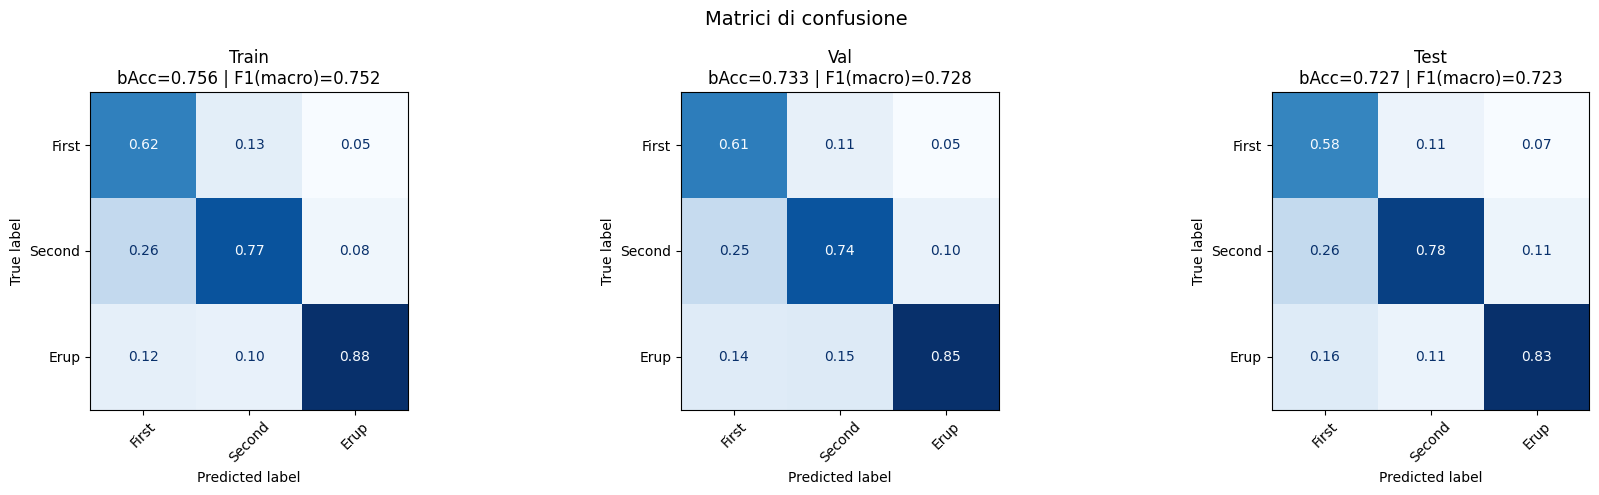

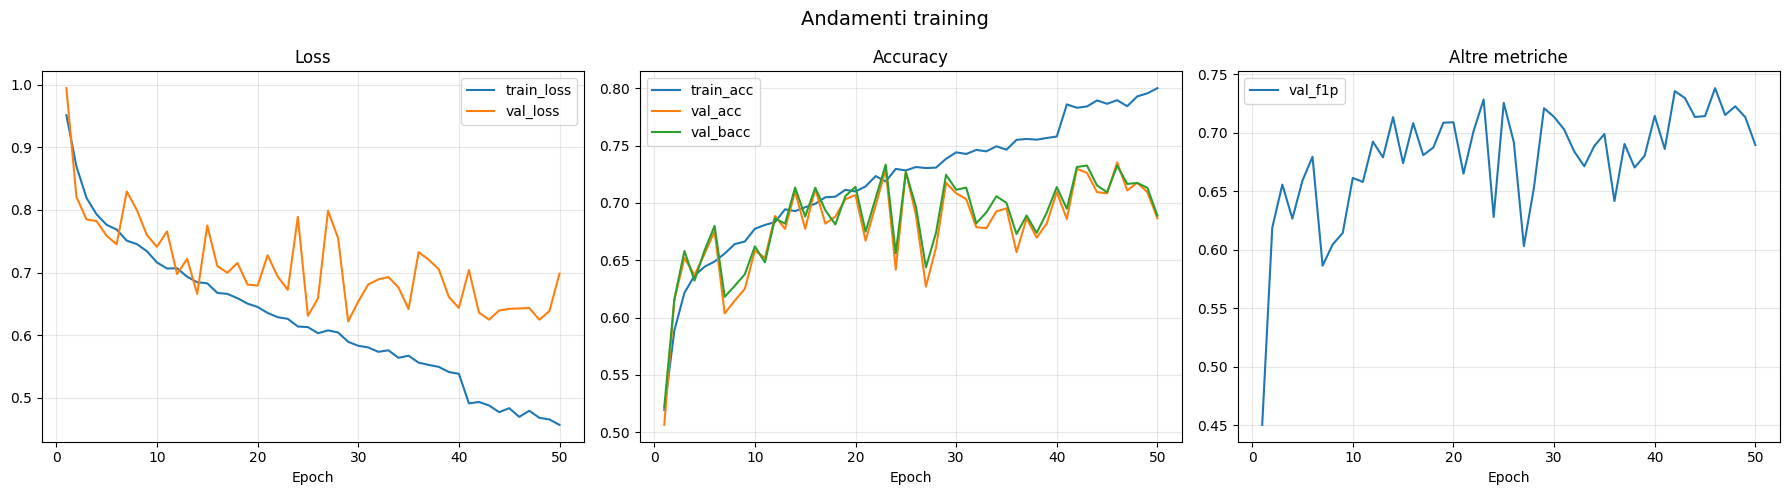

(<Figure size 1800x500 with 3 Axes>, <Figure size 1800x500 with 3 Axes>)

In [ ]:
# Name_Labels = ["First", "Second", "Third", "Fourth", "Erup"]
Name_Labels = ["First", "Second", "Erup"]


# plot_results(TwoD_model,
#              train_loader_Spec, val_loader_Spec, test_loader_Spec,
#              history2D, device=device,
#              class_names=Name_Labels)

plot_results(OneD_model,
             train_loader_Wave, val_loader_Wave, test_loader_Wave,
             history1D, device=device,
             class_names=Name_Labels)